In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/customer-support-tickets-dataset-200k-records/customer_support_tickets_200k.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import classification_report, accuracy_score

from xgboost import XGBClassifier
from scipy.sparse import hstack

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("/kaggle/input/customer-support-tickets-dataset-200k-records/customer_support_tickets_200k.csv")


In [4]:
df.head()
df.shape
df.columns

Index(['ticket_id', 'customer_name', 'customer_email', 'product', 'category',
       'issue_description', 'resolution_notes', 'priority', 'status',
       'channel', 'region', 'customer_age', 'customer_gender',
       'subscription_type', 'customer_tenure_months', 'previous_tickets',
       'customer_satisfaction_score', 'first_response_time_hours',
       'resolution_time_hours', 'ticket_created_date', 'ticket_resolved_date',
       'escalated', 'sla_breached', 'operating_system', 'browser',
       'payment_method', 'language', 'preferred_contact_time',
       'issue_complexity_score', 'customer_segment'],
      dtype='object')

In [5]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ticket_id                    200000 non-null  int64  
 1   customer_name                200000 non-null  object 
 2   customer_email               200000 non-null  object 
 3   product                      200000 non-null  object 
 4   category                     200000 non-null  object 
 5   issue_description            200000 non-null  object 
 6   resolution_notes             200000 non-null  object 
 7   priority                     200000 non-null  object 
 8   status                       200000 non-null  object 
 9   channel                      200000 non-null  object 
 10  region                       200000 non-null  object 
 11  customer_age                 200000 non-null  int64  
 12  customer_gender              200000 non-null  object 
 13 

In [6]:
# Drop useless columns
df = df.drop(columns=['ticket_id', 'customer_name', 'customer_email'])

# Fill missing text
df['issue_description'] = df['issue_description'].fillna("")

In [7]:
le = LabelEncoder()
df['target'] = le.fit_transform(df['category'])

df['category'].value_counts()

category
Feature Request              20169
Subscription Cancellation    20096
Performance Issue            20074
Security Concern             20040
Login Issue                  20002
Payment Problem              19997
Bug Report                   19981
Refund Request               19900
Data Sync Issue              19877
Account Suspension           19864
Name: count, dtype: int64

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


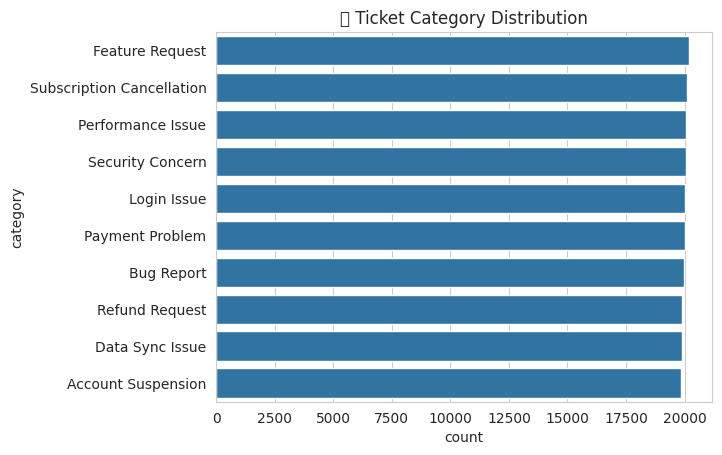

In [8]:
sns.countplot(data=df, y='category', order=df['category'].value_counts().index)
plt.title("📊 Ticket Category Distribution")
plt.show()

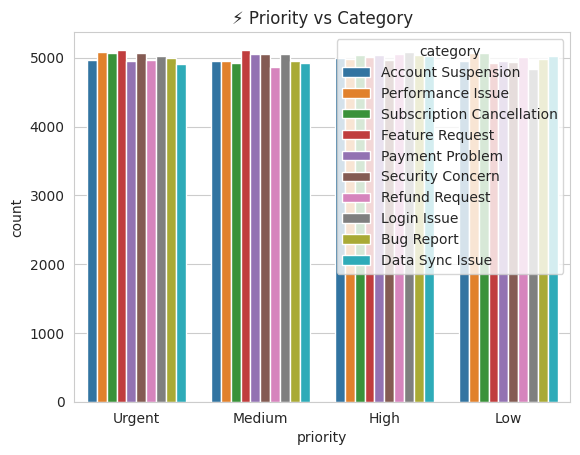

In [9]:
sns.countplot(data=df, x='priority', hue='category')
plt.title("⚡ Priority vs Category")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


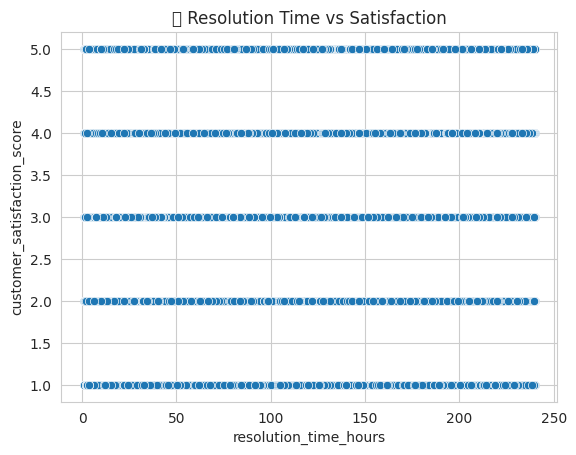

In [10]:
sns.scatterplot(
    data=df,
    x='resolution_time_hours',
    y='customer_satisfaction_score'
)
plt.title("⏱ Resolution Time vs Satisfaction")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


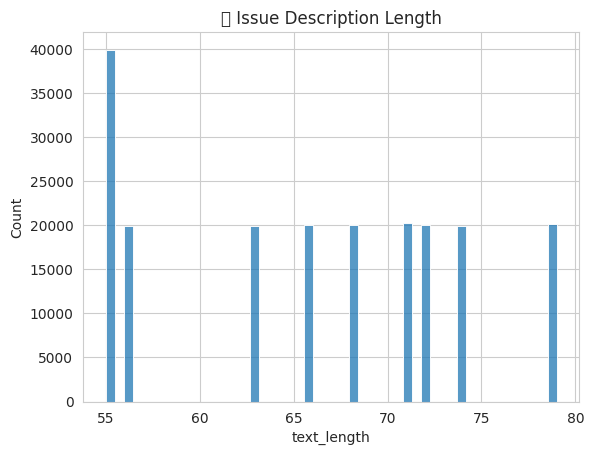

In [11]:
df['text_length'] = df['issue_description'].apply(len)

sns.histplot(df['text_length'], bins=50)
plt.title("📝 Issue Description Length")
plt.show()

In [12]:
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')

X_text = tfidf.fit_transform(df['issue_description'])

In [13]:
tabular_cols = [
    'priority', 'status', 'channel', 'product',
    'customer_age', 'customer_tenure_months',
    'previous_tickets', 'customer_satisfaction_score',
    'first_response_time_hours', 'resolution_time_hours',
    'issue_complexity_score'
]

X_tabular = pd.get_dummies(df[tabular_cols], drop_first=True)

In [14]:
X_tabular = pd.get_dummies(df[tabular_cols], drop_first=True)

# 🔥 CRITICAL FIX
X_tabular = X_tabular.astype(np.float32)

In [15]:
from scipy.sparse import csr_matrix

X_tabular_sparse = csr_matrix(X_tabular)

In [16]:
X = hstack([X_text, X_tabular_sparse])
y = df['target']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
X = hstack([X_text, X_tabular])
y = df['target']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Baseline Model\n")
print(classification_report(y_test, preds))

Baseline Model

              precision    recall  f1-score   support

           0       0.10      0.07      0.08      3973
           1       0.10      0.07      0.08      4009
           2       0.09      0.04      0.06      4013
           3       0.09      0.15      0.11      3941
           4       0.10      0.10      0.10      4022
           5       0.09      0.09      0.09      4006
           6       0.10      0.13      0.11      3967
           7       0.11      0.13      0.12      3983
           8       0.10      0.13      0.11      3949
           9       0.10      0.08      0.09      4137

    accuracy                           0.10     40000
   macro avg       0.10      0.10      0.10     40000
weighted avg       0.10      0.10      0.10     40000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Baseline Model\n")
print(classification_report(y_test, preds))

Baseline Model

              precision    recall  f1-score   support

           0       0.10      0.07      0.08      3973
           1       0.10      0.07      0.08      4009
           2       0.09      0.04      0.06      4013
           3       0.09      0.15      0.11      3941
           4       0.10      0.10      0.10      4022
           5       0.09      0.09      0.09      4006
           6       0.10      0.13      0.11      3967
           7       0.11      0.13      0.12      3983
           8       0.10      0.13      0.11      3949
           9       0.10      0.08      0.09      4137

    accuracy                           0.10     40000
   macro avg       0.10      0.10      0.10     40000
weighted avg       0.10      0.10      0.10     40000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [22]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist'
)

xgb.fit(X_train, y_train)

preds_xgb = xgb.predict(X_test)

print("XGBoost\n")
print(classification_report(y_test, preds_xgb))

XGBoost

              precision    recall  f1-score   support

           0       0.10      0.10      0.10      3973
           1       0.09      0.08      0.09      4009
           2       0.10      0.10      0.10      4013
           3       0.10      0.11      0.11      3941
           4       0.11      0.11      0.11      4022
           5       0.10      0.10      0.10      4006
           6       0.09      0.10      0.10      3967
           7       0.10      0.09      0.10      3983
           8       0.10      0.11      0.11      3949
           9       0.11      0.10      0.10      4137

    accuracy                           0.10     40000
   macro avg       0.10      0.10      0.10     40000
weighted avg       0.10      0.10      0.10     40000



In [23]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist'
)

xgb.fit(X_train, y_train)

preds_xgb = xgb.predict(X_test)

print("XGBoost\n")
print(classification_report(y_test, preds_xgb))

XGBoost

              precision    recall  f1-score   support

           0       0.10      0.10      0.10      3973
           1       0.09      0.08      0.09      4009
           2       0.10      0.10      0.10      4013
           3       0.10      0.11      0.11      3941
           4       0.11      0.11      0.11      4022
           5       0.10      0.10      0.10      4006
           6       0.09      0.10      0.10      3967
           7       0.10      0.09      0.10      3983
           8       0.10      0.11      0.11      3949
           9       0.11      0.10      0.10      4137

    accuracy                           0.10     40000
   macro avg       0.10      0.10      0.10     40000
weighted avg       0.10      0.10      0.10     40000

